# 43 - Covariance of cluster number counts with the tSZ power spectrum (L1_m9)

Empirical reproduction of Hurier & Lacasa (2017), Figure 7
(`ref_literature/plots/hurier_2017_fig7.png`, bispectrum block omitted), on the
**FLAMINGO L1_m9 fiducial** sky, following the nb40 conventions:

* map `y_unlensed_L1_m9_lc0_nside4096.fits`, fiducial feedback only;
* catalogue `halo_catalogue_M500c_5e13_zlt3_L1_m9_yang26rot_qfrommz.csv`
  (A10 $B=1.35$ + scatter $q$, as in `data/nb40_l1_m9_feedback_cnc_qz.npz`);
* number counts: $q>5$, $z<1$, the nb40 10 redshift bins;
* masked spectrum: $5\times\theta_{500}$ discs around $q>5$ clusters
  (same recipe as `Dl_yy_L1_m9_qgt5.txt`);
* $C_\ell$: the last **9 bins with $\ell_{\rm eff}>100$** of the
  project-standard 18-bin log scheme ($\ell_{\rm eff} = 117$ to $959.5$);
  lower bins are too noisy/cut by the patch size.

**Method (patch resampling).** L1_m9 gives a single sky, so a sample covariance
cannot come from sky realizations. Instead the sky is split into the 192
HEALPix $N_{\rm side}=4$ superpixels ($\simeq 215\,\mathrm{deg}^2$ each) and the
joint vector $[\,N_{\rm cl}(z)\,,\;D_\ell\,]$ is measured per patch
(`scripts/export_L1_m9_patch_cnc_ps.py`, cache
`data/nb43_L1_m9_patch_cov/patch_ensemble.npz`). The sample covariance across
patches estimates the joint covariance; to the extent that patches are
independent, the correlation matrix of the full-sky measurement equals the
patch-level one. This is the patch-resampling route anticipated in the joint
CNC + masked-PS project plan.

Two settings, as in the reference figure:

1. **Full sky:** $[\,N_{\rm cl}(z)\,,\; C_\ell^{\rm full}\,]$
2. **Masked:** $[\,N_{\rm cl}(z)\,,\; C_\ell^{\rm masked}(q>5)\,]$

A second, fully independent estimate from the 1000-realization JXPaint painted
benchmark (a synthetic hmfast fiducial, *not* L1_m9) is kept at the end as a
Monte-Carlo cross-check of the qualitative structure.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
})

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
PATCH_NPZ = REPO / "data/nb43_L1_m9_patch_cov/patch_ensemble.npz"
BP_DIR = REPO / "data/bandpowers_L1_m9_feedback"
CNC40_NPZ = REPO / "data/nb40_l1_m9_feedback_cnc_qz.npz"
PS_MC_DIR = Path("/rds/rds-lxu/JXPaint_validation/ps_from_painted_maps")
CNC_MC_NPZ = REPO / "data/nb43_painted_cnc_z.npz"
FIG_DIR = REPO / "figures/nb43_cnc_tsz_ps_covariance"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load the L1_m9 patch ensemble and the stored nb40-convention anchors

In [2]:
pe = np.load(PATCH_NPZ)
assert int(pe["n_done"]) == pe["dl_full"].shape[0], "patch run incomplete"
N_z_p = pe["N_z"]              # (192, 10)  q>5, z<1 counts per patch
dl_full_p = pe["dl_full"]      # (192, 9)
dl_mask_p = pe["dl_mask"]      # (192, 9)
ell_eff = pe["ell_eff"]
z_edges = pe["z_edges"]
z_centres_all = 0.5 * (z_edges[:-1] + z_edges[1:])

# L1_m9 has no q>5 detections beyond z ~ 0.6 (1 Gpc box, few massive high-z
# clusters), so the empty nb40 z bins are dropped from the data vector.
keep_z = N_z_p.sum(axis=0) > 0
print(f"z bins kept (nonzero counts): {keep_z.sum()} of {keep_z.size}, "
      f"z < {z_edges[1:][keep_z].max():.2f}")
N_z_p = N_z_p[:, keep_z]
z_centres = z_centres_all[keep_z]
n_patch, n_z = N_z_p.shape
n_ell = ell_eff.size

# stored single-sky anchors (nb40 convention)
cnc40 = np.load(CNC40_NPZ, allow_pickle=True)
Nz40 = cnc40["Nz"][list(cnc40["variants"]).index("L1_m9")]
bp_full = np.loadtxt(BP_DIR / "Dl_yy_L1_m9_fullsky.txt")
bp_mask = np.loadtxt(BP_DIR / "Dl_yy_L1_m9_qgt5.txt")

print(f"patches: {n_patch}, N_cl z bins: {n_z}, C_ell bins: {n_ell}")
print(f"ell_eff = {ell_eff}")
print(f"clusters q>5, z<1 per patch: mean {N_z_p.sum(axis=1).mean():.2f}, "
      f"max {N_z_p.sum(axis=1).max():.0f}")

# anchor 1: patch counts must sum to the stored nb40 CNC
print(f"\nsum_p N_z  vs nb40 Nz(L1_m9): {N_z_p.sum(axis=0).astype(int)}")
print(f"                              {Nz40.astype(int)}")

# anchor 2: mean patch spectrum vs stored full-sky / masked NaMaster bandpowers
ratio_full = dl_full_p.mean(axis=0) / np.interp(ell_eff, bp_full[:, 0], bp_full[:, 1])
ratio_mask = dl_mask_p.mean(axis=0) / np.interp(ell_eff, bp_mask[:, 0], bp_mask[:, 1])
print(f"\n<D_ell patch>/stored  full sky: {np.round(ratio_full, 3)}")
print(f"<D_ell patch>/stored  masked  : {np.round(ratio_mask, 3)}")

z bins kept (nonzero counts): 6 of 10, z < 0.60
patches: 192, N_cl z bins: 6, C_ell bins: 9
ell_eff = [117.  152.5 198.  257.5 335.5 436.5 567.5 738.  959.5]
clusters q>5, z<1 per patch: mean 5.62, max 14

sum_p N_z  vs nb40 Nz(L1_m9): [270 349 229 141  72  18]
                              [270 349 229 141  72  18   0   0   0   0]

<D_ell patch>/stored  full sky: [1.026 1.023 1.017 1.032 1.02  0.999 1.012 0.999 1.003]
<D_ell patch>/stored  masked  : [0.982 0.989 1.009 0.991 1.002 0.988 1.    0.996 1.004]


## Joint correlation matrices (192 patches)

Data vector $[\,N_{\rm cl}(z)\,,\;D_{\ell_1..\ell_9}\,]$ (non-empty $z$
bins only); sample
covariance across the 192 patches, normalized to a correlation matrix
$R_{ij}=C_{ij}/\sqrt{C_{ii}C_{jj}}$. With 192 samples the statistical noise on
each $R_{ij}$ is $\sim 1/\sqrt{192}\simeq 0.07$, so only $|R|\gtrsim 0.15$ is
meaningful. Layout follows Hurier & Lacasa Fig. 7: origin at the lower left,
$N_{\rm cl}$ block bottom-left, $C_\ell$ block top-right, `jet` colormap over
$[-1,1]$ for direct visual comparison with the reference.

In [3]:
def joint_corr(counts, dl):
    data = np.hstack([counts, dl])
    cov = np.cov(data, rowvar=False, ddof=1)
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)

corr_full = joint_corr(N_z_p, dl_full_p)
corr_mask = joint_corr(N_z_p, dl_mask_p)

def cross_stats(corr, nz):
    cb = corr[:nz, nz:]
    return cb.mean(), np.abs(cb).max()

for tag, c in [("full sky", corr_full), ("masked q>5", corr_mask)]:
    m, mx = cross_stats(c, n_z)
    print(f"{tag:11s}: N_cl x C_ell cross block  mean r = {m:+.3f}, max|r| = {mx:.3f}")

full sky   : N_cl x C_ell cross block  mean r = +0.135, max|r| = 0.377
masked q>5 : N_cl x C_ell cross block  mean r = +0.057, max|r| = 0.237


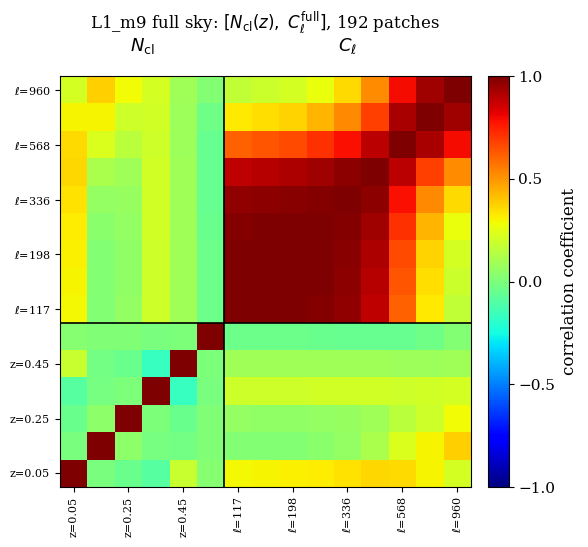

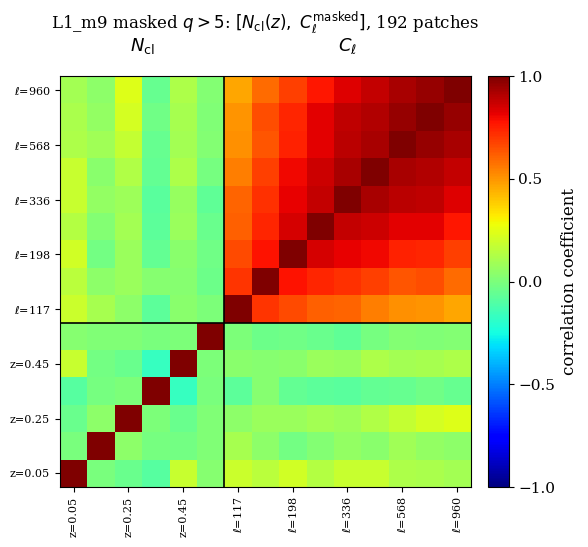

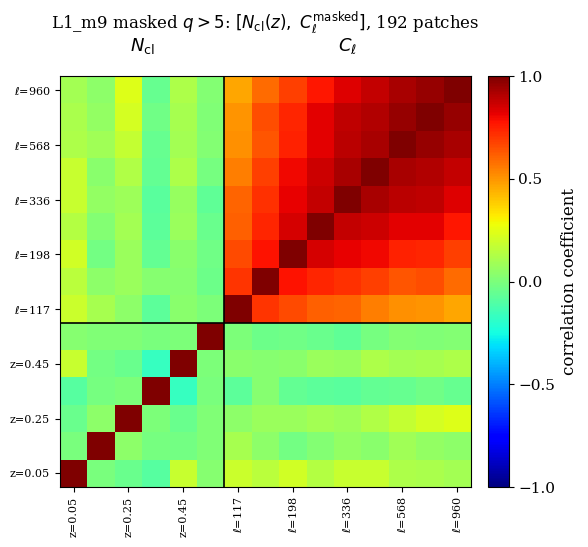

In [4]:
def plot_corr(corr, title, fname, nz, ne, zc, ells):
    fig, ax = plt.subplots(figsize=(6.8, 5.6))
    im = ax.imshow(corr, origin="lower", cmap="jet", vmin=-1.0, vmax=1.0,
                   interpolation="nearest", aspect="equal")
    n = nz + ne
    b = nz - 0.5
    ax.axhline(b, color="k", lw=1.2)
    ax.axvline(b, color="k", lw=1.2)
    ticks = list(range(0, nz, 2)) + [nz + k for k in range(0, ne, 2)]
    labels = [f"z={zc[i]:.2f}" for i in range(0, nz, 2)] +              [rf"$\ell$={ells[k]:.0f}" for k in range(0, ne, 2)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=8)
    ax.text((nz - 1) / 2.0, n + 0.25, r"$N_{\rm cl}$", ha="center", va="bottom", fontsize=13)
    ax.text(nz + (ne - 1) / 2.0, n + 0.25, r"$C_\ell$", ha="center", va="bottom", fontsize=13)
    ax.set_title(title, pad=34)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03,
                        ticks=[-1.0, -0.5, 0.0, 0.5, 1.0])
    cbar.set_label("correlation coefficient")
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{fname}.{ext}", bbox_inches="tight")
    plt.show()
    return fig

plot_corr(corr_full,
          f"L1_m9 full sky: $[N_{{\\rm cl}}(z),\\ C_\\ell^{{\\rm full}}]$, "
          f"{n_patch} patches",
          "corrmat_L1m9_fullsky", n_z, n_ell, z_centres, ell_eff)
plot_corr(corr_mask,
          f"L1_m9 masked $q>5$: $[N_{{\\rm cl}}(z),\\ C_\\ell^{{\\rm masked}}]$, "
          f"{n_patch} patches",
          "corrmat_L1m9_masked", n_z, n_ell, z_centres, ell_eff)

## Cross-correlation, quantified

Correlation of the total count $N(q>5, z<1)$ with each $C_\ell$ bin, in both
settings; the grey band is the $\pm 1/\sqrt{n_{\rm patch}}$ noise level of a
null correlation.

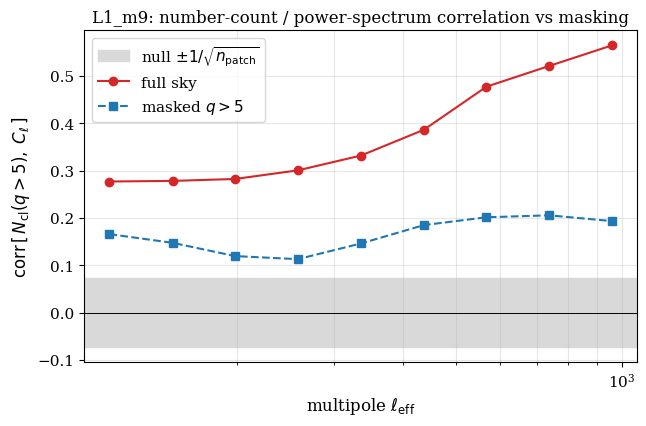

corr[N_tot, C_ell]  full sky: mean +0.380
corr[N_tot, C_ell]  masked  : mean +0.164


In [5]:
Ntot = N_z_p.sum(axis=1)
def corr_with_Ntot(dl):
    return np.array([np.corrcoef(Ntot, dl[:, k])[0, 1] for k in range(n_ell)])

r_full = corr_with_Ntot(dl_full_p)
r_mask = corr_with_Ntot(dl_mask_p)

fig, ax = plt.subplots(figsize=(6.6, 4.4))
sig = 1.0 / np.sqrt(n_patch)
ax.axhspan(-sig, sig, color="0.85", zorder=0, label=r"null $\pm 1/\sqrt{n_{\rm patch}}$")
ax.plot(ell_eff, r_full, "o-", color="C3", label="full sky")
ax.plot(ell_eff, r_mask, "s--", color="C0", label="masked $q>5$")
ax.axhline(0.0, color="k", lw=0.7)
ax.set_xscale("log")
ax.set_xlabel(r"multipole $\ell_{\rm eff}$")
ax.set_ylabel(r"$\mathrm{corr}\,[\,N_{\rm cl}(q>5),\; C_\ell\,]$")
ax.set_title("L1_m9: number-count / power-spectrum correlation vs masking")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"cross_corr_vs_ell.{ext}", bbox_inches="tight")
plt.show()

print(f"corr[N_tot, C_ell]  full sky: mean {r_full.mean():+.3f}")
print(f"corr[N_tot, C_ell]  masked  : mean {r_mask.mean():+.3f}")

## Monte-Carlo cross-check: 1000 painted realizations (JXPaint benchmark)

Independent check of the same structure with a true realization ensemble: 1000
painted Compton-$y$ skies of a synthetic hmfast fiducial (not L1_m9), each with
a matching mock catalogue (`snr_true>5` counts in the same 10 $z$ bins,
`data/nb43_painted_cnc_z.npz`) and full-sky / $q>5$-masked binned spectra in the
same 9 $\ell$ bins (`/rds/rds-lxu/JXPaint_validation/ps_from_painted_maps/`).
Here the covariance is over sky realizations, so it directly estimates the
full-sky joint covariance with no patch approximation.

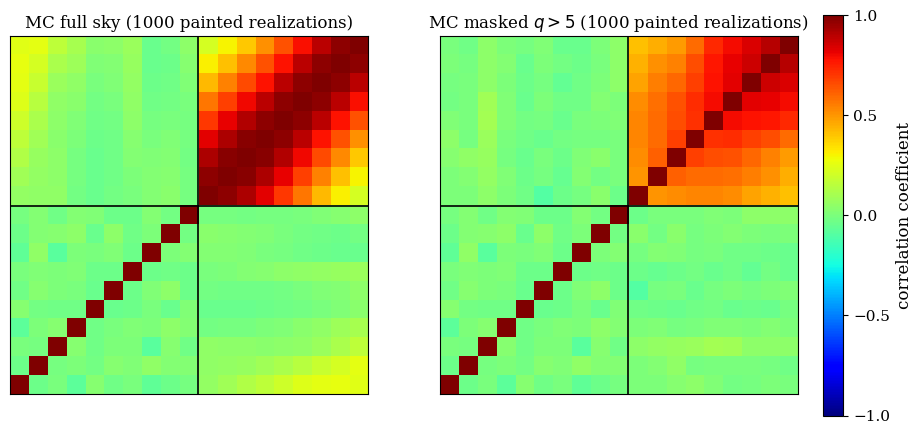

MC corr[N_tot, C_ell] full sky : mean +0.208
MC corr[N_tot, C_ell] masked   : mean +0.016


In [6]:
ell_mc = np.load(PS_MC_DIR / "ell_eff.npy")
sel = ell_mc > 100.0
dl_full_mc = np.load(PS_MC_DIR / "Dl_binned_fullsky_signal_only_all1000.npy")[:, sel]
dl_mask_mc = np.load(PS_MC_DIR / "Dl_binned_masked_signal_only_all1000.npy")[:, sel]
cnc_mc = np.load(CNC_MC_NPZ)
N_z_mc = cnc_mc["N_z"]
assert np.allclose(ell_mc[sel], ell_eff)

corr_full_mc = joint_corr(N_z_mc, dl_full_mc)
corr_mask_mc = joint_corr(N_z_mc, dl_mask_mc)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.2))
for ax, corr, title in [
    (axes[0], corr_full_mc, "MC full sky"),
    (axes[1], corr_mask_mc, "MC masked $q>5$"),
]:
    im = ax.imshow(corr, origin="lower", cmap="jet", vmin=-1, vmax=1,
                   interpolation="nearest")
    b = N_z_mc.shape[1] - 0.5
    ax.axhline(b, color="k", lw=1.2)
    ax.axvline(b, color="k", lw=1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title} (1000 painted realizations)")
cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.03,
                    ticks=[-1, -0.5, 0, 0.5, 1])
cbar.set_label("correlation coefficient")
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"corrmat_painted_mc.{ext}", bbox_inches="tight")
plt.show()

Ntot_mc = N_z_mc.sum(axis=1)
for tag, dl in [("full sky", dl_full_mc), ("masked", dl_mask_mc)]:
    r = np.array([np.corrcoef(Ntot_mc, dl[:, k])[0, 1] for k in range(n_ell)])
    print(f"MC corr[N_tot, C_ell] {tag:9s}: mean {r.mean():+.3f}")

## Conclusions

- On the **L1_m9 fiducial** sky the full-sky tSZ spectrum is positively
  correlated with the $q>5$ number counts: the same massive clusters source
  both, so their Poisson fluctuations couple the two observables
  (off-diagonal $N_{\rm cl}\times C_\ell$ blocks).
- **Masking** the $q>5$ clusters removes those objects from the map and
  strongly suppresses the cross block. A residual patch-level correlation
  ($r \sim 0.1$-$0.2$) survives in L1_m9: within a $\sim 215\,\mathrm{deg}^2$
  patch the same large-scale structure that hosts the detected clusters also
  boosts the unresolved Compton-$y$ background (a 2-halo / super-sample
  coupling), so counts and the masked spectrum are not exactly independent.
- The painted Monte Carlo (unclustered mock positions, true sky-realization
  ensemble) shows the same qualitative structure with the masked cross block
  consistent with zero; the residual L1_m9 masked correlation is therefore the
  clustering contribution, absent by construction in the mocks.
- Neighbouring $C_\ell$ bins are strongly positively correlated in the full-sky
  case (single bright clusters contribute coherently across $\ell$, the 1-halo
  trispectrum), and much less so after masking. This is the content of
  Hurier & Lacasa (2017) Fig. 7, minus their bispectrum block.